In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

In [2]:
import pandas as pd

df = pd.read_csv("../dataset/developer_burnout_dataset_ervin.csv")
df.head()

,age;experience_years;daily_work_hours;sleep_hours;caffeine_intake;bugs_per_day;commits_per_day;meetings_per_day;screen_time;exercise_hours;burnout_level
0,26.0;12.0;10.33;4.45;2.0;11.0;4.0;1.0;15.07;0....
1,39.0;10.0;8.62;5.77;5.0;15.0;11.0;5.0;13.25;0....
2,34.0;13.0;;4.03;5.0;2.0;18.0;9.0;11.18;1.54;Me...
3,30.0;1.0;6.85;6.47;2.0;15.0;26.0;1.0;11.14;0.9...
4,27.0;7.0;4.24;5.8;;9.0;17.0;7.0;8.05;0.36;Low


In [3]:
import pandas as pd
import numpy as np

# 1. Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('../dataset/developer_burnout_dataset_ervin.csv', delimiter=';')

# 2. Menampilkan dimensi awal sebelum dibersihkan
print("=== DESKRIPSI DATASET AWAL ===")
print(f"Jumlah baris data mentah : {df.shape[0]} baris")
print(f"Jumlah kolom/variabel    : {df.shape[1]} kolom")
print("\n=== MENGECEK DATA YANG KOSONG (MISSING VALUES) ===")
print(df.isnull().sum())

=== DESKRIPSI DATASET AWAL ===
Jumlah baris data mentah : 7000 baris
Jumlah kolom/variabel    : 11 kolom

=== MENGECEK DATA YANG KOSONG (MISSING VALUES) ===
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
burnout_level       140
dtype: int64


In [4]:
import pandas as pd
import numpy as np

# 1. Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('../dataset/developer_burnout_dataset_ervin.csv', delimiter=';')

# 2. Menampilkan informasi dimensi awal
print("=== DESKRIPSI DATASET AWAL ===")
print(f"Jumlah baris data mentah : {df.shape[0]} baris")
print(f"Jumlah kolom/variabel    : {df.shape[1]} kolom\n")

# ==========================================================
# 3. MENAMPILKAN DISTRIBUSI KELAS TARGET (TERMASUK DATA HILANG)
# ==========================================================
print("=== DISTRIBUSI KELAS TARGET ===")
nama_kolom_target = 'burnout_level'

if nama_kolom_target in df.columns:
    # Menggunakan dropna=False agar data NaN/Kosong dipaksa muncul
    distribusi = df[nama_kolom_target].value_counts(dropna=False)
    
    for label, jumlah in distribusi.items():
        # Memeriksa apakah baris tersebut merupakan data kosong (NaN)
        if pd.isna(label):
            print(f"Jumlah Data KOSONG (Missing/NaN) : {jumlah} baris  <-- 🔍 TARGET YANG HILANG!")
        else:
            print(f"Jumlah Data {label:<20} : {jumlah} baris")
            
    print("-" * 50)
    print(f"TOTAL KESELURUHAN DATASET        : {distribusi.sum()} baris (Pas 7000!)")
else:
    print(f"Peringatan: Kolom '{nama_kolom_target}' tidak ditemukan!")

print("-" * 50)
print("\n")

# ==========================================================
# 4. MENAMPILKAN MISSING VALUES UNTUK SETIAP FITUR / VARIABEL
# ==========================================================
print("=== PENCEKAN MISSING VALUES PER VARIABEL ===")
# Hitung missing value di setiap kolom
missing_per_kolom = df.isnull().sum()

for kolom, jumlah_missing in missing_per_kolom.items():
    if jumlah_missing > 0:
        print(f"Variabel {kolom:<20} : {jumlah_missing:<5} baris kosong <-- ⚠️ Perlu Imputasi/Cleaning")
    else:
        print(f"Variabel {kolom:<20} : {jumlah_missing:<5} baris kosong (Bersih)")

print("-" * 50)

# Kesimpulan untuk bahan narasi Bab IV Skripsi
print("\n💡 CATATAN ANALISIS UNTUK BAB IV (PREPROCESSING):")
print(f"- Kolom target '{nama_kolom_target}' memiliki {df[nama_kolom_target].isnull().sum()} data kosong yang wajib DIBUANG (Drop Row).")
print("- Fitur-fitur numerik lainnya yang memiliki data kosong nanti akan diatasi pada tahap")
print("  preprocessing menggunakan Nilai Median (Imputasi Median) sebelum masuk ke pemodelan.")
print("="*50)

# ==========================================================
# 5. PREVIEW DATASET INTERAKTIF
# ==========================================================

=== DESKRIPSI DATASET AWAL ===
Jumlah baris data mentah : 7000 baris
Jumlah kolom/variabel    : 11 kolom

=== DISTRIBUSI KELAS TARGET ===
Jumlah Data Medium               : 3485 baris
Jumlah Data High                 : 1782 baris
Jumlah Data Low                  : 1593 baris
Jumlah Data KOSONG (Missing/NaN) : 140 baris  <-- 🔍 TARGET YANG HILANG!
--------------------------------------------------
TOTAL KESELURUHAN DATASET        : 7000 baris (Pas 7000!)
--------------------------------------------------


=== PENCEKAN MISSING VALUES PER VARIABEL ===
Variabel age                  : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel experience_years     : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel daily_work_hours     : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel sleep_hours          : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel caffeine_intake      : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel bugs_per_day         : 140

In [5]:
print(df["burnout_level"].value_counts())

burnout_level
Medium    3485
High      1782
Low       1593
Name: count, dtype: int64


SPLIT DATA TRAINING DAN TESTING
Total data awal : 7000
Total data setelah filter usia 20-35 tahun : 4328
------------------------------------------------------------
Data Training : 3462
Data Testing  : 866
------------------------------------------------------------
Data training berhasil disimpan
Data testing berhasil disimpan


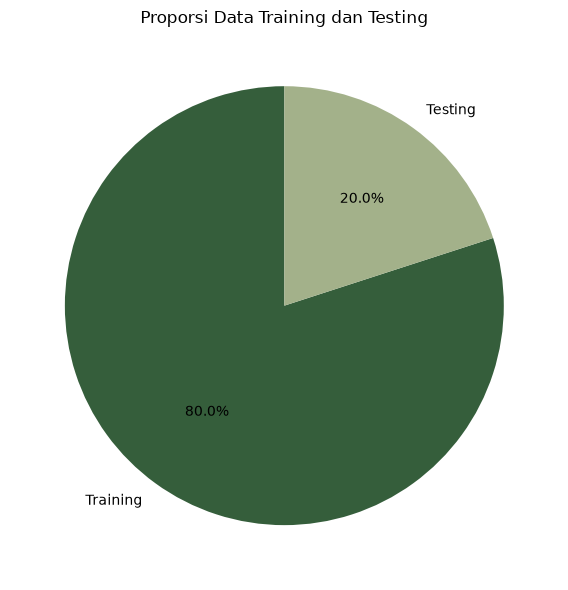

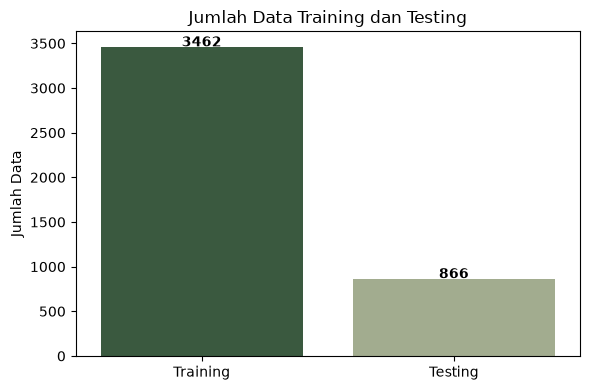

SPLIT DATA BERHASIL


In [6]:
# ==========================================================
# SPLIT DATA TRAINING DAN TESTING + FILTER USIA
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("="*60)
print("SPLIT DATA TRAINING DAN TESTING")
print("="*60)

# ==========================================================
# MEMBACA DATASET
# ==========================================================

df = pd.read_csv("../dataset/developer_burnout_dataset_ervin.csv", delimiter=";")

print(f"Total data awal : {len(df)}")

# ==========================================================
# FILTER USIA 20 - 35 TAHUN
# ==========================================================

df = df[(df["age"] >= 20) & (df["age"] <= 35)].copy()

print(f"Total data setelah filter usia 20-35 tahun : {len(df)}")

# ==========================================================
# SPLIT DATA
# ==========================================================

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("-"*60)
print(f"Data Training : {len(df_train)}")
print(f"Data Testing  : {len(df_test)}")
print("-"*60)

# ==========================================================
# MEMBUAT FOLDER HASIL
# ==========================================================

os.makedirs("../hasil", exist_ok=True)

# ==========================================================
# SIMPAN DATA
# ==========================================================

df_train.to_csv("../hasil/3_data_training.csv", index=False)
df_test.to_csv("../hasil/3_data_testing.csv", index=False)

print("Data training berhasil disimpan")
print("Data testing berhasil disimpan")

# ==========================================================
# GRAFIK PROPORSI TRAIN TEST
# ==========================================================

plt.figure(figsize=(6,6))

plt.pie(
    [len(df_train), len(df_test)],
    labels=["Training","Testing"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#355E3B","#A3B18A"]
)

plt.title("Proporsi Data Training dan Testing")
plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIK JUMLAH DATA
# ==========================================================

visual = pd.DataFrame({
    "Jenis Data":["Training","Testing"],
    "Jumlah":[len(df_train),len(df_test)]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=visual,
    x="Jenis Data",
    y="Jumlah",
    hue="Jenis Data",
    palette=["#355E3B","#A3B18A"],
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2, p.get_height()+5),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Jumlah Data Training dan Testing")
plt.ylabel("Jumlah Data")
plt.xlabel("")

plt.tight_layout()
plt.show()

print("="*60)
print("SPLIT DATA BERHASIL")
print("="*60)

In [7]:
# ==========================================================
# HANDLING MISSING VALUE
# ==========================================================

import pandas as pd

print("="*60)
print("HANDLING MISSING VALUE")
print("="*60)

# ==========================================================
# CEK MISSING VALUE SEBELUM
# ==========================================================

print("\nMissing Value Data Training")

print(df_train.isnull().sum())

print("\nTotal Missing Value Training :", df_train.isnull().sum().sum())

print("-"*60)

print("\nMissing Value Data Testing")

print(df_test.isnull().sum())

print("\nTotal Missing Value Testing :", df_test.isnull().sum().sum())

# ==========================================================
# HAPUS MISSING VALUE
# ==========================================================

jumlah_train_awal = len(df_train)
jumlah_test_awal = len(df_test)

df_train = df_train.dropna().reset_index(drop=True)
df_test = df_test.dropna().reset_index(drop=True)

# ==========================================================
# HASIL SETELAH HANDLING
# ==========================================================

print("\nJumlah Data Setelah Handling")

print("Training :", len(df_train))
print("Testing  :", len(df_test))

print("-"*60)

print("Data Training yang dihapus :", jumlah_train_awal-len(df_train))
print("Data Testing yang dihapus  :", jumlah_test_awal-len(df_test))

print("-"*60)

print("Total Missing Value Setelah Handling")

print("Training :", df_train.isnull().sum().sum())
print("Testing  :", df_test.isnull().sum().sum())

print("="*60)
print("HANDLING MISSING VALUE SELESAI")
print("="*60)

HANDLING MISSING VALUE

Missing Value Data Training
age                  0
experience_years    85
daily_work_hours    71
sleep_hours         71
caffeine_intake     75
bugs_per_day        66
commits_per_day     64
meetings_per_day    62
screen_time         73
exercise_hours      64
burnout_level       72
dtype: int64

Total Missing Value Training : 703
------------------------------------------------------------

Missing Value Data Testing
age                  0
experience_years    15
daily_work_hours    22
sleep_hours         20
caffeine_intake     18
bugs_per_day        14
commits_per_day     15
meetings_per_day    19
screen_time         15
exercise_hours      23
burnout_level       13
dtype: int64

Total Missing Value Testing : 174

Jumlah Data Setelah Handling
Training : 2819
Testing  : 701
------------------------------------------------------------
Data Training yang dihapus : 643
Data Testing yang dihapus  : 165
------------------------------------------------------------
Total M

In [8]:
# ==========================================================
# NORMALISASI DATA (MIN-MAX SCALING)
# ==========================================================

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print("="*60)
print("NORMALISASI DATA (MIN-MAX SCALING)")
print("="*60)

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=["burnout_level"])
y_train = df_train["burnout_level"]

X_test = df_test.drop(columns=["burnout_level"])
y_test = df_test["burnout_level"]

print("\nJumlah Fitur :", X_train.shape[1])

print("Jumlah Data Training :", X_train.shape)

print("Jumlah Data Testing  :", X_test.shape)

print("-"*60)

# ==========================================================
# NORMALISASI
# ==========================================================

scaler = MinMaxScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Normalisasi berhasil dilakukan")

print("-"*60)

# ==========================================================
# GABUNGKAN KEMBALI DENGAN TARGET
# ==========================================================

df_train = X_train.copy()
df_train["burnout_level"] = y_train.reset_index(drop=True)

df_test = X_test.copy()
df_test["burnout_level"] = y_test.reset_index(drop=True)

# ==========================================================
# MENAMPILKAN HASIL
# ==========================================================

print("\nData Training Setelah Normalisasi")

print(df_train.head())

print("-"*60)

print("\nData Testing Setelah Normalisasi")

print(df_test.head())

print("-"*60)

# ==========================================================
# CEK RENTANG NILAI
# ==========================================================

print("Nilai Minimum Training")

print(df_train.drop(columns=["burnout_level"]).min())

print("-"*60)

print("Nilai Maksimum Training")

print(df_train.drop(columns=["burnout_level"]).max())

print("-"*60)

print("Nilai Minimum Testing")

print(df_test.drop(columns=["burnout_level"]).min())

print("-"*60)

print("Nilai Maksimum Testing")

print(df_test.drop(columns=["burnout_level"]).max())

print("="*60)
print("NORMALISASI DATA SELESAI")
print("="*60)

NORMALISASI DATA (MIN-MAX SCALING)

Jumlah Fitur : 10
Jumlah Data Training : (2819, 10)
Jumlah Data Testing  : (701, 10)
------------------------------------------------------------
Normalisasi berhasil dilakukan
------------------------------------------------------------

Data Training Setelah Normalisasi
        age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  0.933333          0.368421          0.609610        0.664         0.000000   
1  0.000000          0.263158          0.848849        0.676         0.285714   
2  0.466667          0.578947          0.294294        0.744         0.285714   
3  0.866667          0.842105          0.641642        0.208         1.000000   
4  0.733333          0.789474          0.416416        0.510         0.714286   

   bugs_per_day  commits_per_day  meetings_per_day  screen_time  \
0      0.210526         1.000000          0.555556     0.617735   
1      0.842105         0.379310          0.444444     0.625186   
2  

In [9]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

import pandas as pd

print("="*60)
print("LABEL ENCODING")
print("="*60)

# ==========================================================
# MAPPING LABEL MANUAL
# ==========================================================

label_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

# ==========================================================
# ENCODING TARGET
# ==========================================================

df_train["burnout_level"] = df_train["burnout_level"].map(label_mapping)

df_test["burnout_level"] = df_test["burnout_level"].map(label_mapping)

print("\nLabel Encoding berhasil dilakukan")

print("-"*60)

# ==========================================================
# MENAMPILKAN MAPPING LABEL
# ==========================================================

print("Mapping Label")

for label, kode in label_mapping.items():
    print(f"{label} = {kode}")

print("-"*60)

# ==========================================================
# CEK HASIL ENCODING
# ==========================================================

print("Distribusi Target Training")

print(df_train["burnout_level"].value_counts().sort_index())

print("-"*60)

print("Distribusi Target Testing")

print(df_test["burnout_level"].value_counts().sort_index())

print("-"*60)

# ==========================================================
# MENAMPILKAN DATA
# ==========================================================

print("\nData Training")

print(df_train.head())

print("-"*60)

print("\nData Testing")

print(df_test.head())

print("-"*60)

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=["burnout_level"])
y_train = df_train["burnout_level"]

X_test = df_test.drop(columns=["burnout_level"])
y_test = df_test["burnout_level"]

print("Ukuran Data Training")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("-"*60)

print("Ukuran Data Testing")

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# VERIFIKASI MAPPING
# ==========================================================

print("Verifikasi Mapping")

print("0 = Low")
print("1 = Medium")
print("2 = High")

print("="*60)
print("LABEL ENCODING SELESAI")
print("="*60)

LABEL ENCODING

Label Encoding berhasil dilakukan
------------------------------------------------------------
Mapping Label
Low = 0
Medium = 1
High = 2
------------------------------------------------------------
Distribusi Target Training
burnout_level
0     663
1    1388
2     768
Name: count, dtype: int64
------------------------------------------------------------
Distribusi Target Testing
burnout_level
0    164
1    387
2    150
Name: count, dtype: int64
------------------------------------------------------------

Data Training
        age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  0.933333          0.368421          0.609610        0.664         0.000000   
1  0.000000          0.263158          0.848849        0.676         0.285714   
2  0.466667          0.578947          0.294294        0.744         0.285714   
3  0.866667          0.842105          0.641642        0.208         1.000000   
4  0.733333          0.789474          0.416416       

SMOTE (OVERSAMPLING DATA TRAINING)

Distribusi Kelas Sebelum SMOTE
burnout_level
0     663
1    1388
2     768
Name: count, dtype: int64

Jumlah Data Training : 2819
------------------------------------------------------------
SMOTE berhasil dilakukan
------------------------------------------------------------
Distribusi Kelas Setelah SMOTE
burnout_level
0    1388
1    1388
2    1388
Name: count, dtype: int64

Jumlah Data Training Setelah SMOTE : 4164
------------------------------------------------------------
Missing Value Setelah SMOTE
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
dtype: int64

Total Missing Value :
0
------------------------------------------------------------
Ukuran Data
X_train_resampled : (4164, 10)
y_train_resampled : (4164,)
X_test : (701, 10)
y_test : (701,)
-----------------------------

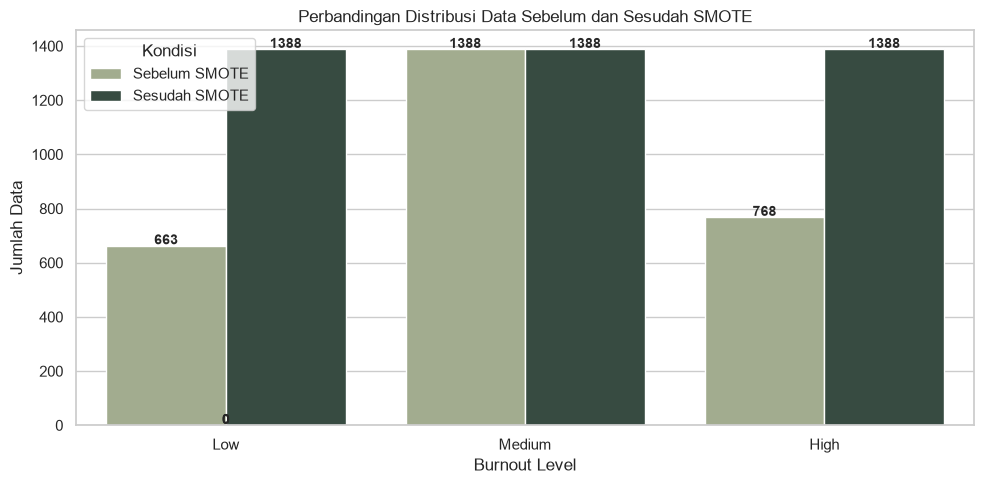

SMOTE SELESAI


In [10]:
# ==========================================================
# SMOTE (OVERSAMPLING DATA TRAINING)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

print("="*60)
print("SMOTE (OVERSAMPLING DATA TRAINING)")
print("="*60)

# ==========================================================
# DISTRIBUSI SEBELUM SMOTE
# ==========================================================

print("\nDistribusi Kelas Sebelum SMOTE")

counts_before = y_train.value_counts().sort_index()

print(counts_before)

print("\nJumlah Data Training :", len(y_train))

print("-"*60)

# ==========================================================
# SMOTE
# ==========================================================

smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE berhasil dilakukan")

print("-"*60)

# ==========================================================
# DISTRIBUSI SESUDAH SMOTE
# ==========================================================

print("Distribusi Kelas Setelah SMOTE")

counts_after = y_train_resampled.value_counts().sort_index()

print(counts_after)

print("\nJumlah Data Training Setelah SMOTE :", len(y_train_resampled))

print("-"*60)

# ==========================================================
# CEK MISSING VALUE
# ==========================================================

print("Missing Value Setelah SMOTE")

print(pd.DataFrame(X_train_resampled).isnull().sum())

print("\nTotal Missing Value :")

print(pd.DataFrame(X_train_resampled).isnull().sum().sum())

print("-"*60)

# ==========================================================
# UKURAN DATA
# ==========================================================

print("Ukuran Data")

print("X_train_resampled :", X_train_resampled.shape)
print("y_train_resampled :", y_train_resampled.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# VISUALISASI
# ==========================================================

before = pd.DataFrame({
    "Kelas":["Low","Medium","High"],
    "Jumlah":counts_before.values,
    "Kondisi":"Sebelum SMOTE"
})

after = pd.DataFrame({
    "Kelas":["Low","Medium","High"],
    "Jumlah":counts_after.values,
    "Kondisi":"Sesudah SMOTE"
})

visual = pd.concat([before,after])

plt.figure(figsize=(10,5))

sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=visual,
    x="Kelas",
    y="Jumlah",
    hue="Kondisi",
    palette=["#A3B18A","#344E41"]
)

for p in ax.patches:

    tinggi = p.get_height()

    ax.annotate(
        f"{int(tinggi)}",
        (
            p.get_x()+p.get_width()/2,
            tinggi+5
        ),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Perbandingan Distribusi Data Sebelum dan Sesudah SMOTE")
plt.xlabel("Burnout Level")
plt.ylabel("Jumlah Data")

plt.tight_layout()
plt.show()

print("="*60)
print("SMOTE SELESAI")
print("="*60)

RANDOM FOREST

Ukuran Data
X_train_resampled : (4164, 10)
y_train_resampled : (4164,)
X_test : (701, 10)
y_test : (701,)
------------------------------------------------------------
Model Random Forest berhasil dilatih
------------------------------------------------------------


STRUKTUR DECISION TREE PERTAMA
|--- meetings_per_day <= 0.64
|   |--- screen_time <= 0.54
|   |   |--- bugs_per_day <= 0.47
|   |   |   |--- daily_work_hours <= 0.56
|   |   |   |   |--- age <= 0.99
|   |   |   |   |   |--- meetings_per_day <= 0.44
|   |   |   |   |   |   |--- commits_per_day <= 0.93
|   |   |   |   |   |   |   |--- experience_years <= 0.47
|   |   |   |   |   |   |   |   |--- experience_years <= 0.47
|   |   |   |   |   |   |   |   |   |--- age <= 0.93
|   |   |   |   |   |   |   |   |   |   |--- sleep_hours <= 0.19
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |   |--- sleep_hours >  0.19
|   |   |   |   |   |   |   |   |   

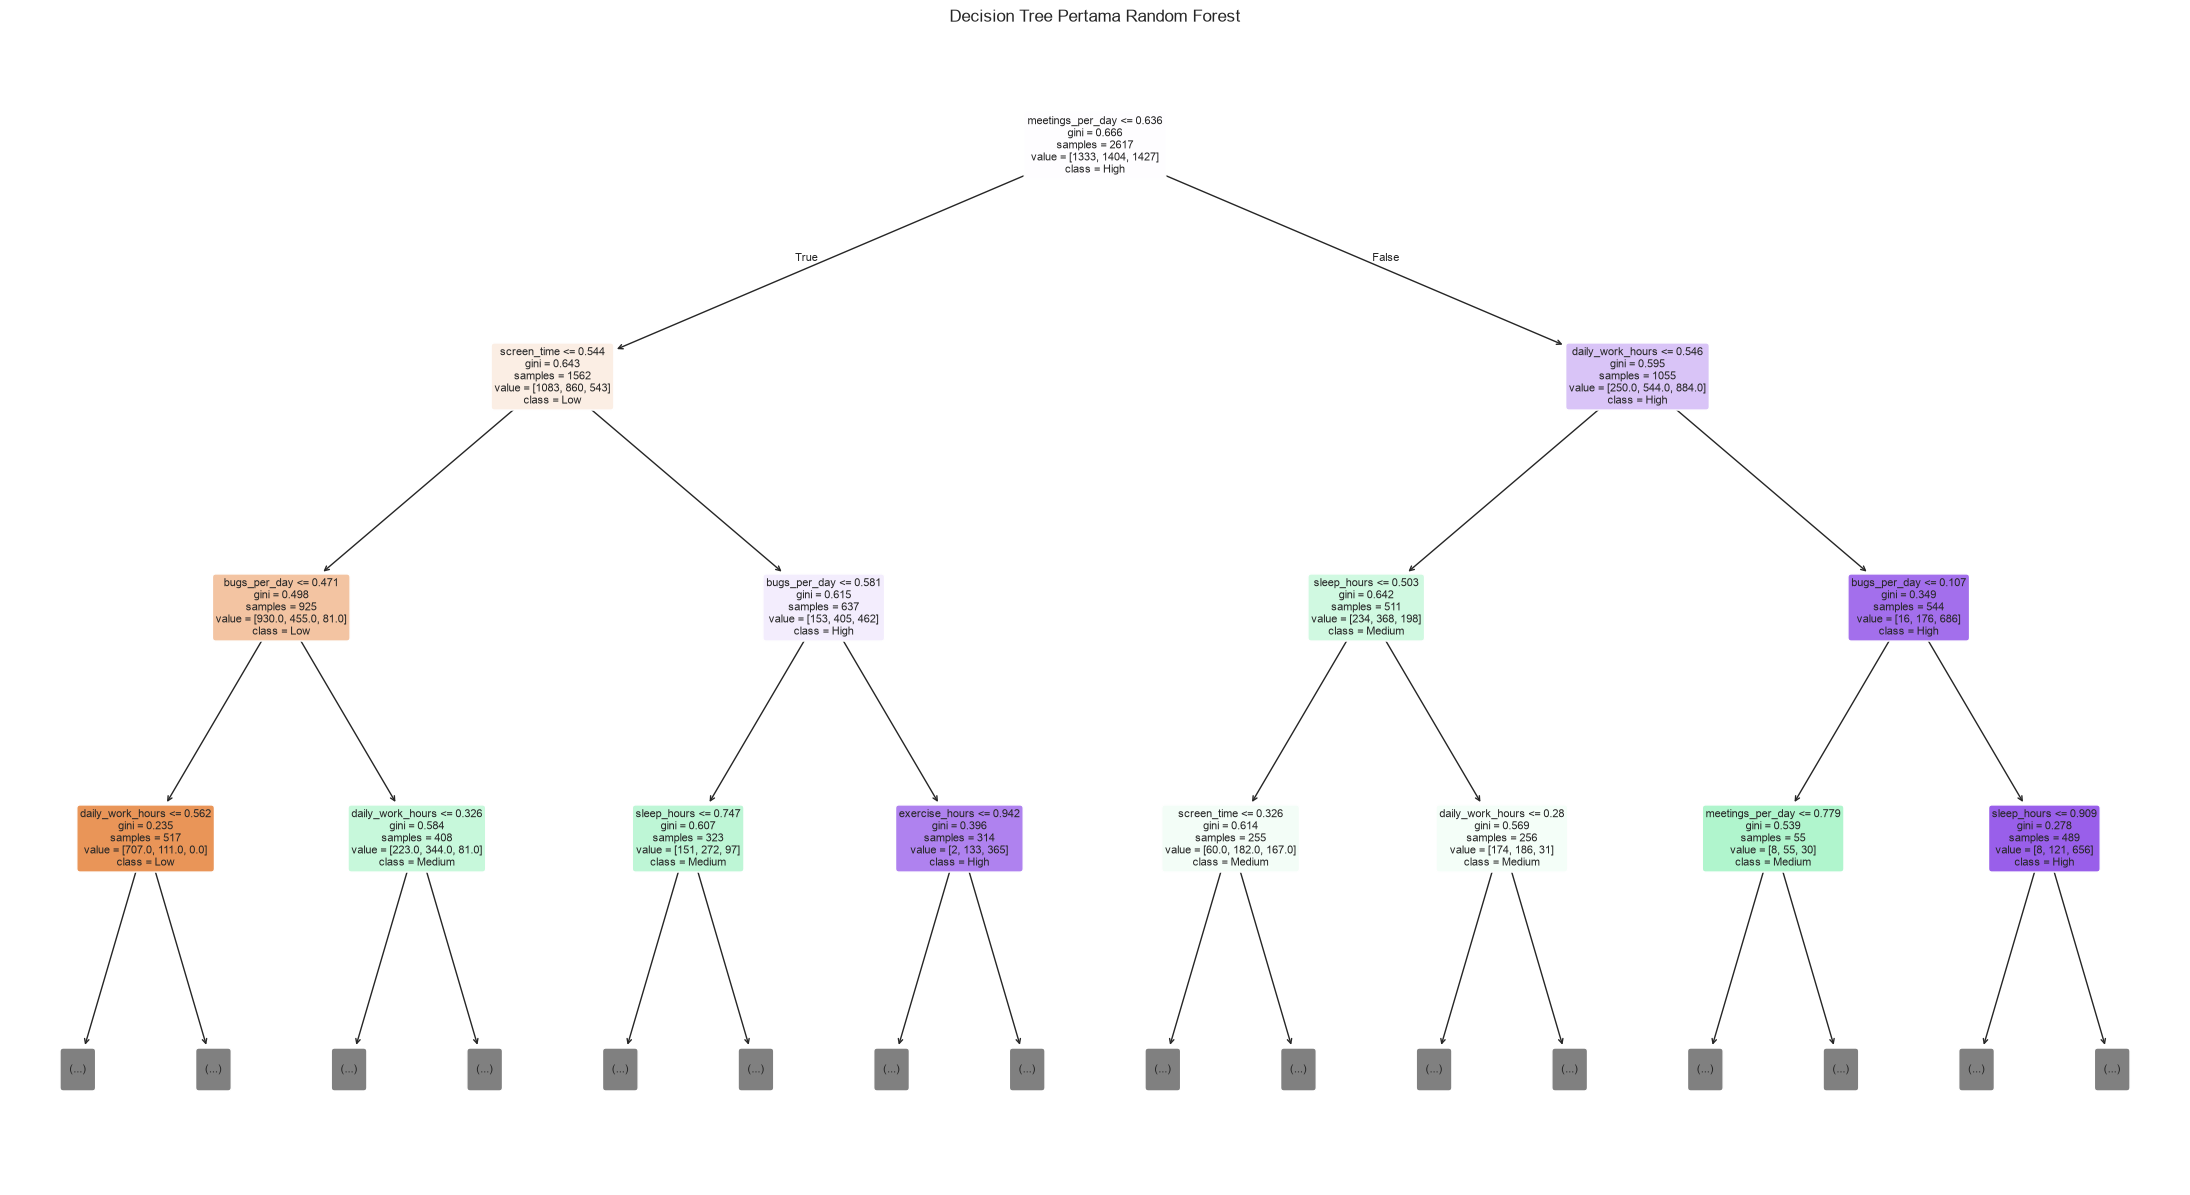

Prediksi selesai
------------------------------------------------------------
Accuracy : 78.60%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.76      0.79      0.78       164
      Medium       0.82      0.79      0.80       387
        High       0.74      0.77      0.75       150

    accuracy                           0.79       701
   macro avg       0.77      0.78      0.78       701
weighted avg       0.79      0.79      0.79       701

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict Medium  Predict High
Actual Low             130              34             0
Actual Medium           41             306            40
Actual High              0              35           115
------------------------------------------------------------


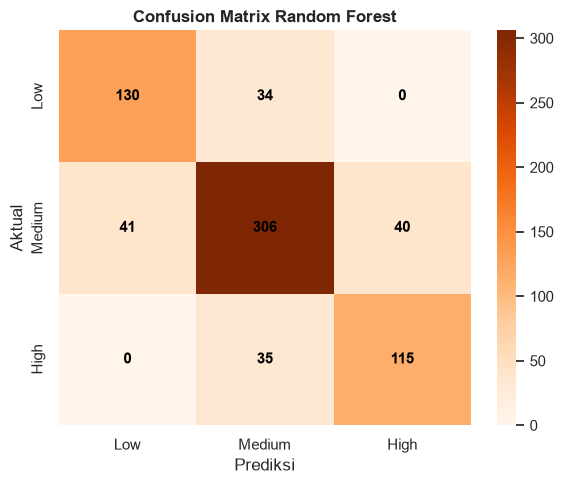

RANDOM FOREST SELESAI

PERHITUNGAN 2 DATA SAMPEL RANDOM FOREST

Data Sampel 1
age                 0.800000
experience_years    0.526316
daily_work_hours    0.449449
sleep_hours         0.922000
caffeine_intake     0.285714
bugs_per_day        0.526316
commits_per_day     0.586207
meetings_per_day    0.888889
screen_time         0.558122
exercise_hours      0.510000
Name: 0, dtype: float64

Data Sampel 2
age                 0.266667
experience_years    0.052632
daily_work_hours    0.339339
sleep_hours         0.606000
caffeine_intake     0.000000
bugs_per_day        0.052632
commits_per_day     0.310345
meetings_per_day    0.000000
screen_time         0.406855
exercise_hours      0.565000
Name: 1, dtype: float64

Label Aktual
Data 1 : 1
Data 2 : 0
------------------------------------------------------------

Jumlah Pohon (N_tree) : 100

Contoh Probabilitas dari 5 Pohon Pertama (Data 1)
         Low  Medium  High
Pohon 1  0.0     0.0   1.0
Pohon 2  0.0     0.0   1.0
Pohon 3  0.0     1.0 

In [11]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("RANDOM FOREST")
print("="*60)

# ==========================================================
# CEK UKURAN DATA
# ==========================================================

print("\nUkuran Data")

print("X_train_resampled :", X_train_resampled.shape)
print("y_train_resampled :", y_train_resampled.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

# ==========================================================
# TRAINING
# ==========================================================

rf_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Model Random Forest berhasil dilatih")
print("-"*60)

# ==========================================================
# MENAMPILKAN STRUKTUR TREE PERTAMA
# ==========================================================

from sklearn.tree import export_text
from sklearn.tree import plot_tree

print("\n")
print("="*60)
print("STRUKTUR DECISION TREE PERTAMA")
print("="*60)

tree_1 = rf_model.estimators_[0]

tree_text = export_text(
    tree_1,
    feature_names=list(X_train_resampled.columns)
)

print(tree_text)

# ==========================================================
# VISUALISASI TREE PERTAMA
# ==========================================================

plt.figure(figsize=(28,15))

plot_tree(
    tree_1,
    feature_names=X_train_resampled.columns,
    class_names=["Low", "Medium", "High"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Decision Tree Pertama Random Forest")
plt.savefig("tree_pertama_rf.png", dpi=150, bbox_inches="tight")
plt.show()

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_rf = rf_model.predict(X_test)

print("Prediksi selesai")
print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy : {:.2f}%".format(accuracy*100))
print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Low", "Medium", "High"]
    )
)
print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred_rf)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Predict Low", "Predict Medium", "Predict High"]
)

print("Confusion Matrix\n")
print(cm_df)
print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))
sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
    annot_kws={"fontsize":11, "fontweight":"bold", "color":"black"}
)

plt.title("Confusion Matrix Random Forest", fontsize=12, fontweight="bold")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()

print("="*60)
print("RANDOM FOREST SELESAI")
print("="*60)


# ==========================================================
# PERHITUNGAN MANUAL 2 DATA SAMPEL RANDOM FOREST
# ==========================================================
# Catatan:
# Random Forest terdiri atas banyak decision tree independen
# (di sini n_estimators=100) yang masing-masing dilatih dari
# subset data (bootstrap) dan subset fitur secara acak. Karena
# tidak realistis menelusuri struktur 100 pohon satu per satu,
# perhitungan manual di bawah ini mengambil OUTPUT PROBABILITAS
# tiap pohon (yang sudah dihasilkan oleh model terlatih), lalu
# menunjukkan proses AGREGASI (rata-rata / soft voting) secara
# manual hingga menghasilkan probabilitas akhir dan keputusan
# klasifikasi (argmax) -- sama seperti proses softmax pada
# XGBoost dan decision function pada SVM.

print("\n" + "="*60)
print("PERHITUNGAN 2 DATA SAMPEL RANDOM FOREST")
print("="*60)

sample_idx = [0, 1]
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

print("\nData Sampel 1")
print(X_sample.iloc[0])

print("\nData Sampel 2")
print(X_sample.iloc[1])

print("\nLabel Aktual")
print("Data 1 :", y_sample.iloc[0])
print("Data 2 :", y_sample.iloc[1])
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 1 : Mengambil Probabilitas Prediksi Setiap Pohon
# ----------------------------------------------------------
# P_k^(t)(x) = probabilitas kelas k menurut pohon ke-t
# Setiap pohon di Random Forest mengeluarkan probabilitas
# berdasarkan proporsi kelas pada leaf node tempat sampel jatuh.

n_trees = len(rf_model.estimators_)
print(f"\nJumlah Pohon (N_tree) : {n_trees}")

X_sample_array = X_sample.values  # tiap pohon di-fit tanpa nama kolom,
                                   # jadi input juga harus tanpa nama kolom
                                   # agar tidak muncul UserWarning

all_tree_proba = np.array([
    tree.predict_proba(X_sample_array) for tree in rf_model.estimators_
])
# shape: (n_trees, n_data, n_class)

print("\nContoh Probabilitas dari 5 Pohon Pertama (Data 1)")
contoh_df = pd.DataFrame(
    all_tree_proba[:5, 0, :],
    columns=["Low", "Medium", "High"],
    index=[f"Pohon {i+1}" for i in range(5)]
)
print(contoh_df.round(4))

print("\nContoh Probabilitas dari 5 Pohon Pertama (Data 2)")
contoh_df2 = pd.DataFrame(
    all_tree_proba[:5, 1, :],
    columns=["Low", "Medium", "High"],
    index=[f"Pohon {i+1}" for i in range(5)]
)
print(contoh_df2.round(4))
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 2 : Menghitung Rata-Rata Probabilitas (Soft Voting)
# ----------------------------------------------------------
#                1     N_tree
#   P_k(x)  =  ----- * SUM     P_k^(t)(x)
#              N_tree   t=1

print("\nPerhitungan Rata-Rata Probabilitas (Soft Voting) Manual")

manual_proba = []

for i in range(len(X_sample)):
    print(f"\nData {i+1}")
    proba_semua_pohon = all_tree_proba[:, i, :]   # (n_trees, n_class)

    jumlah_proba = np.sum(proba_semua_pohon, axis=0)
    print("Jumlah proba seluruh pohon :", np.round(jumlah_proba, 6))

    rata_rata_proba = jumlah_proba / n_trees
    print("Rata-rata proba (P_k)      :", np.round(rata_rata_proba, 6))

    manual_proba.append(rata_rata_proba)

manual_proba = np.array(manual_proba)
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 3 : Verifikasi dengan predict_proba() Model
# ----------------------------------------------------------

proba_model = rf_model.predict_proba(X_sample)

print("\nProbabilitas dari Model (predict_proba)")
proba_df = pd.DataFrame(
    proba_model,
    columns=["Low", "Medium", "High"],
    index=["Data 1", "Data 2"]
)
print(proba_df.round(6))

print("\nSelisih Manual vs Model (harus mendekati 0)")
print(np.round(manual_proba - proba_model, 8))
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 4 : Klasifikasi Akhir (Argmax)
# ----------------------------------------------------------
#   y_hat = argmax_k  P_k(x)

label_map = {0: "Low", 1: "Medium", 2: "High"}
pred_manual = np.argmax(manual_proba, axis=1)

print("\nHasil Klasifikasi (Argmax)")
for i in range(len(pred_manual)):
    print(f"Data {i+1} = {label_map[pred_manual[i]]} ({pred_manual[i]})")
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 5 : Evaluasi Hasil Manual vs Label Aktual
# ----------------------------------------------------------

print("\nEvaluasi Hasil")
for i in range(len(pred_manual)):
    status = "Prediksi Benar" if pred_manual[i] == y_sample.iloc[i] else "Prediksi Salah"
    print(f"Data {i+1} : {status}")

print("\n" + "="*60)
print("PERHITUNGAN MANUAL RANDOM FOREST SELESAI")
print("="*60)

XGBOOST

Ukuran Data
X_train_resampled : (4164, 10)
y_train_resampled : (4164,)
X_test : (701, 10)
y_test : (701,)
------------------------------------------------------------
Model XGBoost berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 77.46%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.75      0.80      0.78       164
      Medium       0.82      0.76      0.79       387
        High       0.71      0.77      0.73       150

    accuracy                           0.77       701
   macro avg       0.76      0.78      0.77       701
weighted avg       0.78      0.77      0.78       701

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict Medium  Predict High
Actual Low             132         

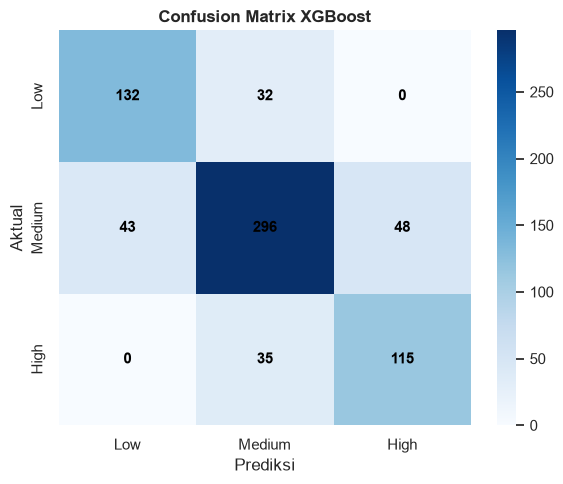

XGBOOST SELESAI

PERHITUNGAN 2 DATA SAMPEL XGBOOST

Data Sampel 1
age                 0.800000
experience_years    0.526316
daily_work_hours    0.449449
sleep_hours         0.922000
caffeine_intake     0.285714
bugs_per_day        0.526316
commits_per_day     0.586207
meetings_per_day    0.888889
screen_time         0.558122
exercise_hours      0.510000
Name: 0, dtype: float64

Data Sampel 2
age                 0.266667
experience_years    0.052632
daily_work_hours    0.339339
sleep_hours         0.606000
caffeine_intake     0.000000
bugs_per_day        0.052632
commits_per_day     0.310345
meetings_per_day    0.000000
screen_time         0.406855
exercise_hours      0.565000
Name: 1, dtype: float64

Label Aktual
Data 1 : 1
Data 2 : 0
------------------------------------------------------------

Raw Margin Score (Log-Odds) Tiap Kelas
             Low    Medium      High
Data 1 -1.263506  0.453388 -1.600182
Data 2  3.343312 -0.788282 -4.690712
-------------------------------------------

In [12]:
# ==========================================================
# XGBOOST
# ==========================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("XGBOOST")
print("="*60)

# ==========================================================
# CEK UKURAN DATA
# ==========================================================

print("\nUkuran Data")

print("X_train_resampled :", X_train_resampled.shape)
print("y_train_resampled :", y_train_resampled.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# ==========================================================
# TRAINING
# ==========================================================

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Model XGBoost berhasil dilatih")
print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_xgb = xgb_model.predict(X_test)

print("Prediksi selesai")
print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(y_test, y_pred_xgb)
print("Accuracy : {:.2f}%".format(accuracy*100))
print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Low", "Medium", "High"]
    )
)
print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred_xgb)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Predict Low", "Predict Medium", "Predict High"]
)

print("Confusion Matrix\n")
print(cm_df)
print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))
sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
    annot_kws={"fontsize":11, "fontweight":"bold", "color":"black"}
)

plt.title("Confusion Matrix XGBoost", fontsize=12, fontweight="bold")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.savefig("confusion_matrix_xgboost.png", dpi=150)
plt.show()

print("="*60)
print("XGBOOST SELESAI")
print("="*60)


# ==========================================================
# PERHITUNGAN MANUAL 2 DATA SAMPEL XGBOOST
# ==========================================================
# Catatan:
# XGBoost multi-class terdiri dari banyak decision tree (di sini
# n_estimators=100) yang skornya dijumlahkan per kelas:
#   f_hat(x) = sum_{t=1}^{T} f_t(x)
# sehingga tidak realistis dihitung ulang split demi split secara
# manual. Perhitungan manual di bawah ini mengambil OUTPUT MENTAH
# (raw margin / log-odds) yang sudah dihasilkan oleh seluruh pohon
# tersebut (hasil akumulasi f_1(x) + f_2(x) + ... + f_100(x)),
# lalu menunjukkan proses SOFTMAX secara manual hingga menghasilkan
# probabilitas dan keputusan klasifikasi akhir (argmax) -- sama
# seperti perhitungan decision function pada SVM.

print("\n" + "="*60)
print("PERHITUNGAN 2 DATA SAMPEL XGBOOST")
print("="*60)

sample_idx = [0, 1]
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

print("\nData Sampel 1")
print(X_sample.iloc[0])

print("\nData Sampel 2")
print(X_sample.iloc[1])

print("\nLabel Aktual")
print("Data 1 :", y_sample.iloc[0])
print("Data 2 :", y_sample.iloc[1])
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 1 : Mengambil Raw Score (Margin / Log-Odds) per Kelas
# ----------------------------------------------------------
# f_hat_k(x) = jumlah output seluruh pohon (n_estimators) untuk kelas k
# raw_margin berbentuk (n_data, n_class) -> 1 nilai log-odds / kelas

raw_margin = xgb_model.predict(X_sample, output_margin=True)

print("\nRaw Margin Score (Log-Odds) Tiap Kelas")
margin_df = pd.DataFrame(
    raw_margin,
    columns=["Low", "Medium", "High"],
    index=["Data 1", "Data 2"]
)
print(margin_df.round(6))
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 2 : Menghitung Softmax Secara Manual
# ----------------------------------------------------------
#            exp(z_k)
#   p_k = -----------------      untuk k = Low, Medium, High
#          Sum exp(z_j)  (j=1..K)

print("\nPerhitungan Softmax Manual")

manual_proba = []

for i, z in enumerate(raw_margin):
    print(f"\nData {i+1}")
    print("z (raw margin)   :", np.round(z, 6))

    exp_z = np.exp(z)
    print("exp(z)           :", np.round(exp_z, 6))

    sum_exp = np.sum(exp_z)
    print("Sigma exp(z)     :", round(sum_exp, 6))

    prob = exp_z / sum_exp
    print("Softmax (p_k)    :", np.round(prob, 6))

    manual_proba.append(prob)

manual_proba = np.array(manual_proba)
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 3 : Verifikasi dengan predict_proba() Model
# ----------------------------------------------------------

proba_model = xgb_model.predict_proba(X_sample)

print("\nProbabilitas dari Model (predict_proba)")
proba_df = pd.DataFrame(
    proba_model,
    columns=["Low", "Medium", "High"],
    index=["Data 1", "Data 2"]
)
print(proba_df.round(6))

print("\nSelisih Manual vs Model (harus mendekati 0)")
print(np.round(manual_proba - proba_model, 8))
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 4 : Klasifikasi Akhir (Argmax)
# ----------------------------------------------------------
#   y_hat = argmax_k  p_k

label_map = {0: "Low", 1: "Medium", 2: "High"}
pred_manual = np.argmax(manual_proba, axis=1)

print("\nHasil Klasifikasi (Argmax)")
for i in range(len(pred_manual)):
    print(f"Data {i+1} = {label_map[pred_manual[i]]} ({pred_manual[i]})")
print("-"*60)

# ----------------------------------------------------------
# LANGKAH 5 : Evaluasi Hasil Manual vs Label Aktual
# ----------------------------------------------------------

print("\nEvaluasi Hasil")
for i in range(len(pred_manual)):
    status = "Prediksi Benar" if pred_manual[i] == y_sample.iloc[i] else "Prediksi Salah"
    print(f"Data {i+1} : {status}")

print("\n" + "="*60)
print("PERHITUNGAN MANUAL XGBOOST SELESAI")
print("="*60)

SUPPORT VECTOR MACHINE (SVM)

Ukuran Data
X_train_resampled : (4164, 10)
y_train_resampled : (4164,)
X_test : (701, 10)
y_test : (701,)
------------------------------------------------------------
Model SVM berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 80.17%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.75      0.85      0.80       164
      Medium       0.87      0.75      0.81       387
        High       0.73      0.88      0.80       150

    accuracy                           0.80       701
   macro avg       0.78      0.83      0.80       701
weighted avg       0.81      0.80      0.80       701

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict Medium  Predict High
Actual Low        

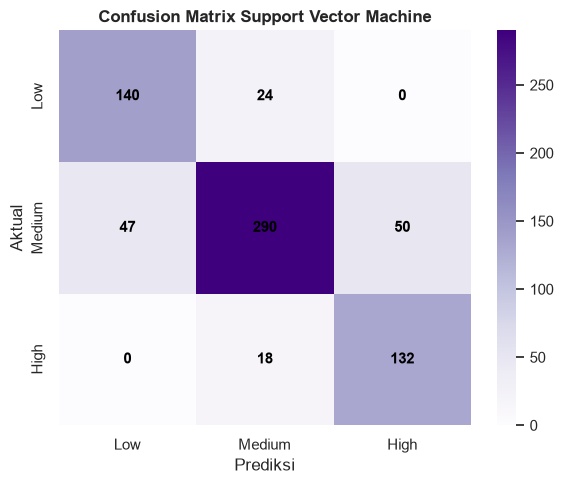

SUPPORT VECTOR MACHINE SELESAI

PERHITUNGAN 2 DATA SAMPEL SVM

Data Sampel 1
age                 0.800000
experience_years    0.526316
daily_work_hours    0.449449
sleep_hours         0.922000
caffeine_intake     0.285714
bugs_per_day        0.526316
commits_per_day     0.586207
meetings_per_day    0.888889
screen_time         0.558122
exercise_hours      0.510000
Name: 0, dtype: float64

Data Sampel 2
age                 0.266667
experience_years    0.052632
daily_work_hours    0.339339
sleep_hours         0.606000
caffeine_intake     0.000000
bugs_per_day        0.052632
commits_per_day     0.310345
meetings_per_day    0.000000
screen_time         0.406855
exercise_hours      0.565000
Name: 1, dtype: float64

Label Aktual
Data 1 : 1
Data 2 : 0

Jarak Euclidean
1.348681

Gamma
1.1728913104952823

Kernel RBF
0.11843

Decision Function
[[ 0.85970954  2.24277613 -0.22049895]
 [ 2.28431073  1.04864643 -0.28551249]]

Prediksi
Data 1 = Medium (1)
Data 2 = Low (0)

Evaluasi Hasil
Data 1 : Pr

In [13]:
# ==========================================================
# SUPPORT VECTOR MACHINE (SVM)
# ==========================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

# ==========================================================
# CEK UKURAN DATA
# ==========================================================

print("\nUkuran Data")

print("X_train_resampled :", X_train_resampled.shape)
print("y_train_resampled :", y_train_resampled.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

# ==========================================================
# TRAINING
# ==========================================================

svm_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Model SVM berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_svm = svm_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Low",
        "Actual Medium",
        "Actual High"
    ],
    columns=[
        "Predict Low",
        "Predict Medium",
        "Predict High"
    ]
)

print("Confusion Matrix\n")

print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    annot_kws={
        "fontsize":11,
        "fontweight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix Support Vector Machine",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("SUPPORT VECTOR MACHINE SELESAI")
print("="*60)


# ==========================================================
# PERHITUNGAN MANUAL SVM (2 DATA SAMPEL)
# ==========================================================

print("\n" + "="*60)
print("PERHITUNGAN 2 DATA SAMPEL SVM")
print("="*60)

# Label mapping untuk ditampilkan
label_map = {0: "Low", 1: "Medium", 2: "High"}

# Ambil 2 data sampel dari X_test (baris ke-1 dan ke-2)
sample_1 = X_test.iloc[0]
sample_2 = X_test.iloc[1]

label_1 = y_test.iloc[0]
label_2 = y_test.iloc[1]

print("\nData Sampel 1")
print(sample_1)

print("\nData Sampel 2")
print(sample_2)

print("\nLabel Aktual")
print("Data 1 :", label_1)
print("Data 2 :", label_2)

# ----------------------------------------------------------
# 1. Menghitung Jarak Euclidean
# ----------------------------------------------------------

euclidean_dist = np.sqrt(np.sum((sample_1 - sample_2) ** 2))

print("\nJarak Euclidean")
print(round(euclidean_dist, 6))

# ----------------------------------------------------------
# 2. Mengambil Nilai Gamma dari Model (gamma='scale')
# ----------------------------------------------------------

gamma_value = svm_model._gamma

print("\nGamma")
print(gamma_value)

# ----------------------------------------------------------
# 3. Menghitung Kernel RBF
#    K(x,y) = exp(-gamma * ||x-y||^2)
# ----------------------------------------------------------

rbf_kernel = np.exp(-gamma_value * (euclidean_dist ** 2))

print("\nKernel RBF")
print(round(rbf_kernel, 5))

# ----------------------------------------------------------
# 4. Menghitung Decision Function untuk kedua sampel
# ----------------------------------------------------------

sample_df = pd.DataFrame([sample_1, sample_2])

decision_scores = svm_model.decision_function(sample_df)

print("\nDecision Function")
print(decision_scores)

# ----------------------------------------------------------
# 5. Prediksi Akhir (berdasarkan nilai Decision Function tertinggi)
# ----------------------------------------------------------

predictions = svm_model.predict(sample_df)

print("\nPrediksi")
print("Data 1 =", label_map[predictions[0]], f"({predictions[0]})")
print("Data 2 =", label_map[predictions[1]], f"({predictions[1]})")

# ----------------------------------------------------------
# 6. Evaluasi Hasil (bandingkan prediksi dengan label aktual)
# ----------------------------------------------------------

print("\nEvaluasi Hasil")
print("Data 1 :", "Prediksi Benar" if predictions[0] == label_1 else "Prediksi Salah")
print("Data 2 :", "Prediksi Benar" if predictions[1] == label_2 else "Prediksi Salah")

# ----------------------------------------------------------
# 7. Kesimpulan
# ----------------------------------------------------------

print("\nKesimpulan")
print(f"Kernel RBF : {round(rbf_kernel, 5)}")
print("Model berhasil mengklasifikasikan kedua data menggunakan fungsi Decision Function.")
print("="*60)

PERBANDINGAN AKURASI MODEL
    Algoritma  Akurasi (%)
          SVM    80.171184
Random Forest    78.601997
      XGBoost    77.460770


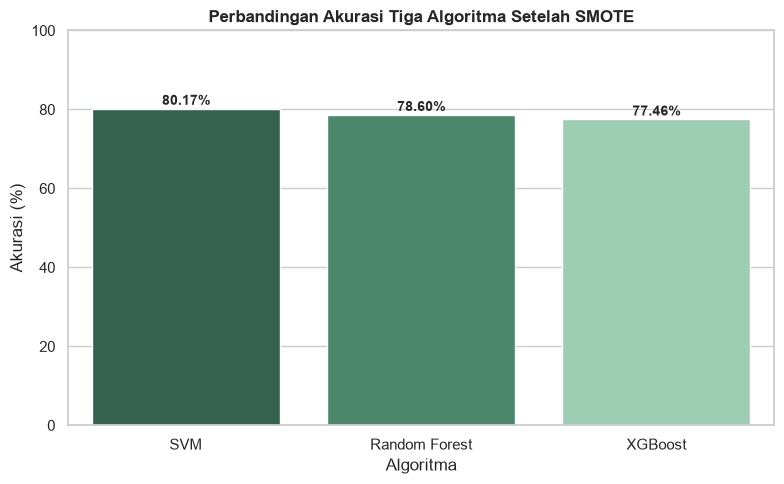

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

# ==========================================================
# HITUNG AKURASI MASING-MASING MODEL
# ==========================================================

# Random Forest
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf) * 100

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100

# SVM
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm) * 100


# ==========================================================
# TABEL PERBANDINGAN AKURASI
# ==========================================================

hasil = pd.DataFrame({
    "Algoritma": [
        "Random Forest",
        "XGBoost",
        "SVM"
    ],
    "Akurasi (%)": [
        acc_rf,
        acc_xgb,
        acc_svm
    ]
})

# Urutkan berdasarkan akurasi terbesar
hasil = hasil.sort_values(
    by="Akurasi (%)",
    ascending=False
).reset_index(drop=True)

print("="*50)
print("PERBANDINGAN AKURASI MODEL")
print("="*50)
print(hasil.to_string(index=False))


# ==========================================================
# VISUALISASI GRAFIK
# ==========================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=hasil,
    x="Algoritma",
    y="Akurasi (%)",
    hue="Algoritma",
    palette=["#2D6A4F", "#40916C", "#95D5B2"],
    legend=False
)

# Menampilkan angka di atas batang
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 1
        ),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Perbandingan Akurasi Tiga Algoritma Setelah SMOTE",
    fontsize=12,
    fontweight='bold'
)

plt.xlabel("Algoritma")
plt.ylabel("Akurasi (%)")
plt.ylim(0,100)

plt.tight_layout()
plt.show()